# Notebook 02 — Tokenizer Comparison
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Compare 6 tokenizers (3 monolingual, 3 multilingual) on code-switched and monolingual texts using quantitative metrics: fertility, OOV rate, sequence-length inflation, vocabulary coverage, and per-language fertility.

**Tokenizers:** BERT (EN), BETO (ES), GPT-2 (EN), mBERT, XLM-RoBERTa, mT5


## 1. Setup
Install dependencies and import libraries.


In [3]:
!pip install -q transformers datasets langid sentencepiece protobuf

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import langid
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

from transformers import AutoTokenizer
from datasets import load_dataset

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
COLOR_PALETTE = sns.color_palette("husl", n_colors=10).as_hex()
sns.set_palette(COLOR_PALETTE)

print("✅ All imports OK")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ All imports OK


## 2. Utility Functions
All metric and plotting functions from `src/utils.py`, copied here so the notebook is self-contained on Kaggle.


In [4]:
def compute_fertility(tokenizer, texts, word_tokenizer=None):
    """Mean subword tokens per whitespace word."""
    split_fn = word_tokenizer if word_tokenizer is not None else str.split
    per_text = []
    for text in texts:
        words = split_fn(text)
        if len(words) == 0:
            per_text.append(0.0)
            continue
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        per_text.append(len(token_ids) / len(words))
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_oov_rate(tokenizer, texts):
    """Percentage of [UNK] tokens."""
    unk_id = getattr(tokenizer, "unk_token_id", None)
    per_text = []
    for text in texts:
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        if len(token_ids) == 0:
            per_text.append(0.0)
            continue
        if unk_id is not None:
            n_unk = sum(1 for tid in token_ids if tid == unk_id)
            per_text.append((n_unk / len(token_ids)) * 100.0)
        else:
            per_text.append(0.0)
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_sequence_length_inflation(tokenizer, texts):
    """Ratio of token count to word count."""
    per_text = []
    for text in texts:
        words = text.split()
        if len(words) == 0:
            per_text.append(0.0)
            continue
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        per_text.append(len(token_ids) / len(words))
    return {"per_text": per_text, "mean": float(np.mean(per_text)) if per_text else 0.0}


def compute_vocabulary_coverage(tokenizer, texts):
    """Percentage of words tokenized as a single token."""
    total_words = 0
    single_token_words = 0
    for text in texts:
        for word in text.split():
            total_words += 1
            token_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(token_ids) == 1:
                single_token_words += 1
    coverage = (single_token_words / total_words * 100.0) if total_words else 0.0
    return {"coverage_pct": coverage, "total_words": total_words, "single_token_words": single_token_words}


def tokenize_and_analyze(tokenizer, texts, tokenizer_name=""):
    """Run all metrics, return summary dict."""
    fertility = compute_fertility(tokenizer, texts)
    oov = compute_oov_rate(tokenizer, texts)
    inflation = compute_sequence_length_inflation(tokenizer, texts)
    coverage = compute_vocabulary_coverage(tokenizer, texts)
    return {
        "tokenizer_name": tokenizer_name,
        "mean_fertility": fertility["mean"],
        "mean_oov_rate": oov["mean"],
        "mean_seq_inflation": inflation["mean"],
        "vocab_coverage": coverage["coverage_pct"],
    }


def plot_fertility_comparison(results_df, save_path=None):
    """Bar chart: fertility across tokenizers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(results_df["tokenizer_name"], results_df["mean_fertility"],
                  color=COLOR_PALETTE[:len(results_df)], edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xlabel("Tokenizer", fontsize=13)
    ax.set_ylabel("Mean Fertility (subwords / word)", fontsize=13)
    ax.set_title("Subword Fertility Comparison", fontsize=15, fontweight="bold")
    ax.tick_params(axis="x", rotation=25, labelsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_sequence_length_comparison(results_df, save_path=None):
    """Bar chart: sequence-length inflation across tokenizers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(results_df["tokenizer_name"], results_df["mean_seq_inflation"],
                  color=COLOR_PALETTE[:len(results_df)], edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=1, label="No inflation")
    ax.set_xlabel("Tokenizer", fontsize=13)
    ax.set_ylabel("Mean Sequence-Length Inflation", fontsize=13)
    ax.set_title("Sequence-Length Inflation Comparison", fontsize=15, fontweight="bold")
    ax.tick_params(axis="x", rotation=25, labelsize=11)
    ax.legend(fontsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_token_distribution(tokenizer, texts, tokenizer_name="", save_path=None):
    """Histogram: tokens per sentence."""
    token_counts = [len(tokenizer.encode(t, add_special_tokens=False)) for t in texts]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(token_counts, bins="auto", color=COLOR_PALETTE[0], edgecolor="white", alpha=0.85)
    mean_c = float(np.mean(token_counts))
    ax.axvline(x=mean_c, color=COLOR_PALETTE[3], linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_c:.1f}")
    suffix = f" ({tokenizer_name})" if tokenizer_name else ""
    ax.set_xlabel("Tokens per Sentence", fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_title(f"Token-Count Distribution{suffix}", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def detect_language_per_token(text):
    """Detect language of each word via langid."""
    results = []
    for word in text.split():
        lang, _ = langid.classify(word)
        results.append((word, lang))
    return results


def per_language_fertility(tokenizer, texts_with_lang_labels):
    """Fertility per language group."""
    lang_subword_counts = defaultdict(list)
    for sentence in texts_with_lang_labels:
        for word, lang in sentence:
            token_ids = tokenizer.encode(word, add_special_tokens=False)
            lang_subword_counts[lang].append(len(token_ids))
    return {lang: float(np.mean(counts)) for lang, counts in sorted(lang_subword_counts.items())}


print("✅ All utility functions defined")


✅ All utility functions defined


## 3. Load Data & Tokenizers

**Datasets:**
| Dataset | Languages | Size | Source |
|---------|-----------|------|--------|
| CS Hindi-English | Hindi + English (Romanized) | 2020 | CMU Hinglish DoG + synthetic |
| CS Spanish-English | Spanish + English | 40 | Synthetic |
| Mono English / Spanish / Hindi | Single language | 500 each | WikiANN |

**Tokenizers:** BERT (EN), BETO (ES), GPT-2 (EN), mBERT, XLM-RoBERTa, mT5


In [5]:
# --- Hinglish (Hindi-English) real data ---
print("Loading CMU Hinglish DoG...")
hinglish_ds = load_dataset("cmu_hinglish_dog", split="train", trust_remote_code=True)

hinglish_texts = []
for row in hinglish_ds:
    utterances = row["translation"]["hi_en"]
    if isinstance(utterances, list):
        hinglish_texts.extend([u.strip() for u in utterances if u.strip()])
    elif isinstance(utterances, str) and utterances.strip():
        hinglish_texts.append(utterances.strip())

hinglish_texts = hinglish_texts[:2000]
print(f"  Hinglish texts: {len(hinglish_texts)}")

# --- Monolingual baselines from WikiANN ---
print("Loading WikiANN (en, es, hi)...")
wiki_en = load_dataset("wikiann", "en", split="train", trust_remote_code=True)
wiki_es = load_dataset("wikiann", "es", split="train", trust_remote_code=True)
wiki_hi = load_dataset("wikiann", "hi", split="train", trust_remote_code=True)

mono_en_texts = [" ".join(row["tokens"]) for row in wiki_en.select(range(500))]
mono_es_texts = [" ".join(row["tokens"]) for row in wiki_es.select(range(500))]
mono_hi_texts = [" ".join(row["tokens"]) for row in wiki_hi.select(range(500))]
print(f"  Mono EN: {len(mono_en_texts)}, Mono ES: {len(mono_es_texts)}, Mono HI: {len(mono_hi_texts)}")

# --- Synthetic Code-Switched: Spanish-English (expanded to 40) ---
cs_spaeng_texts = [
    "Hey, vamos to the store porque necesitamos milk.",
    "I told María que no puedo ir a la fiesta tonight.",
    "Ella said que tiene mucho homework para mañana.",
    "Can you pasar me the sal, por favor?",
    "We were caminando por el park when it started lloviendo.",
    "Mi abuela makes the best tamales, you have to probarlos.",
    "I need to llamar a mi mamá before we leave.",
    "The profesor said que el examen is going to be difícil.",
    "Vamos a the movies tonight, quiero ver esa película nueva.",
    "She always mezcla English and Spanish cuando habla conmigo.",
    "No entiendo why he doesn't querer come to the party.",
    "La biblioteca is closed hoy, so we can't estudiar there.",
    "I forgot to comprar the ingredients para la cena.",
    "Él siempre drives muy rápido, me pone nerviosa.",
    "Let's hacer a barbacoa este weekend en mi backyard.",
    "Mi hermano is studying ingeniería at the university.",
    "Necesito encontrar a new job porque this one no paga bien.",
    "The vecinos are muy ruidosos, I can't dormir at night.",
    "Quiero aprender to play guitarra like my tío Carlos.",
    "We should celebrar her cumpleaños with a big fiesta.",
    "Ayer fuimos al mall and compramos muchas cosas on sale.",
    "My coworker siempre llega tarde and the jefe gets enojado.",
    "Estoy cansada de cooking every night, let's pedir comida.",
    "El perro was barking toda la noche, nobody could sleep.",
    "I have que terminar this proyecto before viernes.",
    "Vamos a la playa this weekend si el weather is bueno.",
    "She told me que su novio is from Argentina.",
    "Tengo hambre, let's get some tacos en ese lugar nuevo.",
    "Mi roommate nunca cleans the cocina, it's so annoying.",
    "The doctor dijo que necesito más exercise y less estrés.",
    "No puedo creer que they canceled the concierto!",
    "Estamos planning a trip to México para las holidays.",
    "He always olvida to lock la puerta when he leaves.",
    "Quiero comprar a new carro pero no tengo enough dinero.",
    "La maestra was very impressed con mi presentación.",
    "We need to arreglar the faucet en el baño, está leaking.",
    "Mi prima wants to become a doctora cuando she grows up.",
    "Esa canción is stuck en mi cabeza all day long.",
    "Let's reunirnos at the café después de classes.",
    "I was leyendo un libro when de repente the lights went out.",
]

# --- Synthetic Code-Switched: Hindi-English ---
cs_hineng_texts = [
    "Yaar, this movie is bahut amazing, let's watch it again.",
    "I need to finish my kaam before the deadline tomorrow.",
    "She is bohot smart, usko sab aata hai in class.",
    "Let's go to the mandir after lunch, it's nearby.",
    "Mujhe lagta hai we should order kuch khana online.",
    "That chai was itni acchi, I want another cup.",
    "My dost is coming from India next hafte.",
    "Uska ghar is really bada, with a huge garden.",
    "I told him ki wo galat hai but he didn't listen.",
    "Yeh weather is so garmi, I can't step bahar.",
    "Aaj ka din was really productive at the office.",
    "Mere paas no time hai for all this bakwas.",
    "She sings bohot accha, everyone loves her awaaz.",
    "We went shopping and bought bahut saari cheezein.",
    "Papa said ki hume jaldi ghar aana hai tonight.",
    "This paratha with chai is the best nashta ever.",
    "Humne decide kiya ki we will go by train.",
    "Isko samjhao that this is not the right tarika.",
    "Main bohot thak gaya after the gym session today.",
    "Kal raat I had a terrible sapna about exams.",
]

# Combine code-switched texts
all_hineng_texts = cs_hineng_texts + hinglish_texts  # 20 + 2000 = 2020
all_spaeng_texts = cs_spaeng_texts  # 40

print(f"\n--- Final dataset sizes ---")
print(f"  CS Hindi-English:   {len(all_hineng_texts)} texts")
print(f"  CS Spanish-English: {len(all_spaeng_texts)} texts")
print(f"  Mono English:       {len(mono_en_texts)} texts")
print(f"  Mono Spanish:       {len(mono_es_texts)} texts")
print(f"  Mono Hindi:         {len(mono_hi_texts)} texts")
print("✅ Data loaded")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cmu_hinglish_dog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CMU Hinglish DoG...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/844k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/99.6k [00:00<?, ?B/s]

...

hi/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

  Mono EN: 500, Mono ES: 500, Mono HI: 500

--- Final dataset sizes ---
  CS Hindi-English:   2020 texts
  CS Spanish-English: 40 texts
  Mono English:       500 texts
  Mono Spanish:       500 texts
  Mono Hindi:         500 texts
✅ Data loaded


In [6]:
# ============================================================
# 2. Load Tokenizers
# ============================================================

TOKENIZER_SPECS = {
    "BERT (EN)":     "bert-base-uncased",
    "BETO (ES)":     "dccuchile/bert-base-spanish-wwm-uncased",
    "GPT-2 (EN)":    "openai-community/gpt2",
    "mBERT":         "bert-base-multilingual-cased",
    "XLM-R":         "xlm-roberta-base",
    "mT5":           "google/mt5-base",
}

tokenizers = {}
for name, model_id in TOKENIZER_SPECS.items():
    print(f"Loading {name} ({model_id})...")
    tokenizers[name] = AutoTokenizer.from_pretrained(model_id)

# Quick sanity check
test_sentence = "Hey, vamos to the store porque necesitamos milk."
print(f"\n--- Sanity check on: '{test_sentence}' ---")
for name, tok in tokenizers.items():
    tokens = tok.tokenize(test_sentence)
    print(f"  {name:12s} → {len(tokens):3d} tokens: {tokens[:10]}{'...' if len(tokens) > 10 else ''}")

print("\n✅ All 6 tokenizers loaded")

Loading BERT (EN) (bert-base-uncased)...
Loading BETO (ES) (dccuchile/bert-base-spanish-wwm-uncased)...


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565



--- Sanity check on: 'Hey, vamos to the store porque necesitamos milk.' ---
  BERT (EN)    →  15 tokens: ['hey', ',', 'va', '##mos', 'to', 'the', 'store', 'por', '##que', 'nec']...
  BETO (ES)    →  12 tokens: ['hey', ',', 'vamos', 'to', 'the', 'stor', '##e', 'porque', 'necesitamos', 'mil']...
  GPT-2 (EN)   →  17 tokens: ['Hey', ',', 'Ġv', 'am', 'os', 'Ġto', 'Ġthe', 'Ġstore', 'Ġpor', 'que']...
  mBERT        →  14 tokens: ['Hey', ',', 'va', '##mos', 'to', 'the', 'store', 'porque', 'ne', '##cesi']...
  XLM-R        →  10 tokens: ['▁Hey', ',', '▁vamos', '▁to', '▁the', '▁store', '▁porque', '▁necesitamos', '▁milk', '.']
  mT5          →  13 tokens: ['▁Hey', ',', '▁', 'vamos', '▁to', '▁the', '▁store', '▁', 'porque', '▁necesita']...

✅ All 6 tokenizers loaded


## 3. Experiment 1 — Aggregate Tokenization Metrics

We run all 6 tokenizers on every dataset (2 code-switched + 3 monolingual) and compute four core metrics:

| Metric | What it measures |
|--------|-----------------|
| **Fertility** | Average subword tokens per word (lower = better) |
| **OOV Rate** | % of `[UNK]` tokens (lower = better) |
| **Seq-Length Inflation** | Ratio of token count to word count (closer to 1.0 = better) |
| **Vocab Coverage** | % of words kept as a single token (higher = better) |

In [7]:
DATASETS = {
    "CS Hindi-Eng":   all_hineng_texts,
    "CS Spanish-Eng": all_spaeng_texts,
    "Mono English":   mono_en_texts,
    "Mono Spanish":   mono_es_texts,
    "Mono Hindi":     mono_hi_texts,
}

all_results = []

for ds_name, texts in DATASETS.items():
    print(f"\n📊 Dataset: {ds_name} ({len(texts)} texts)")
    for tok_name, tok in tokenizers.items():
        result = tokenize_and_analyze(tok, texts, tokenizer_name=tok_name)
        result["dataset"] = ds_name
        all_results.append(result)
        print(f"  {tok_name:12s} | fertility={result['mean_fertility']:.3f}  "
              f"OOV={result['mean_oov_rate']:.2f}%  "
              f"inflation={result['mean_seq_inflation']:.3f}  "
              f"coverage={result['vocab_coverage']:.1f}%")

results_df = pd.DataFrame(all_results)
print(f"\n✅ Done — {len(results_df)} rows (6 tokenizers × 5 datasets)")
results_df.head(12)



📊 Dataset: CS Hindi-Eng (2020 texts)
  BERT (EN)    | fertility=1.726  OOV=0.00%  inflation=1.726  coverage=47.8%
  BETO (ES)    | fertility=1.915  OOV=0.10%  inflation=1.915  coverage=33.4%
  GPT-2 (EN)   | fertility=1.848  OOV=0.00%  inflation=1.848  coverage=39.2%
  mBERT        | fertility=1.771  OOV=0.00%  inflation=1.771  coverage=46.5%
  XLM-R        | fertility=1.526  OOV=0.00%  inflation=1.526  coverage=59.9%
  mT5          | fertility=1.620  OOV=0.00%  inflation=1.620  coverage=51.3%

📊 Dataset: CS Spanish-Eng (40 texts)
  BERT (EN)    | fertility=1.650  OOV=0.00%  inflation=1.650  coverage=59.3%
  BETO (ES)    | fertility=1.444  OOV=1.34%  inflation=1.444  coverage=68.2%
  GPT-2 (EN)   | fertility=1.703  OOV=0.00%  inflation=1.703  coverage=50.9%
  mBERT        | fertility=1.410  OOV=0.00%  inflation=1.410  coverage=70.6%
  XLM-R        | fertility=1.331  OOV=0.00%  inflation=1.331  coverage=74.5%
  mT5          | fertility=1.632  OOV=0.00%  inflation=1.632  coverage=52.8%


,tokenizer_name,mean_fertility,mean_oov_rate,mean_seq_inflation,vocab_coverage,dataset
0,BERT (EN),1.725749,0.000000,1.725749,47.766804,CS Hindi-Eng
1,BETO (ES),1.914820,0.104555,1.914820,33.428022,CS Hindi-Eng
2,GPT-2 (EN),1.847571,0.000000,1.847571,39.214230,CS Hindi-Eng
3,mBERT,1.770931,0.000000,1.770931,46.516913,CS Hindi-Eng
4,XLM-R,1.525780,0.000000,1.525780,59.946683,CS Hindi-Eng
5,mT5,1.620466,0.000000,1.620466,51.346036,CS Hindi-Eng
6,BERT (EN),1.650139,0.000000,1.650139,59.317585,CS Spanish-Eng
7,BETO (ES),1.443971,1.339782,1.443971,68.241470,CS Spanish-Eng
8,GPT-2 (EN),1.703100,0.000000,1.703100,50.918635,CS Spanish-Eng
9,mBERT,1.409880,0.000000,1.409880,70.603675,CS Spanish-Eng


## 4. Visualization — Fertility Comparison

Bar charts showing mean fertility per tokenizer, split by dataset. Lower fertility = less fragmentation = better.


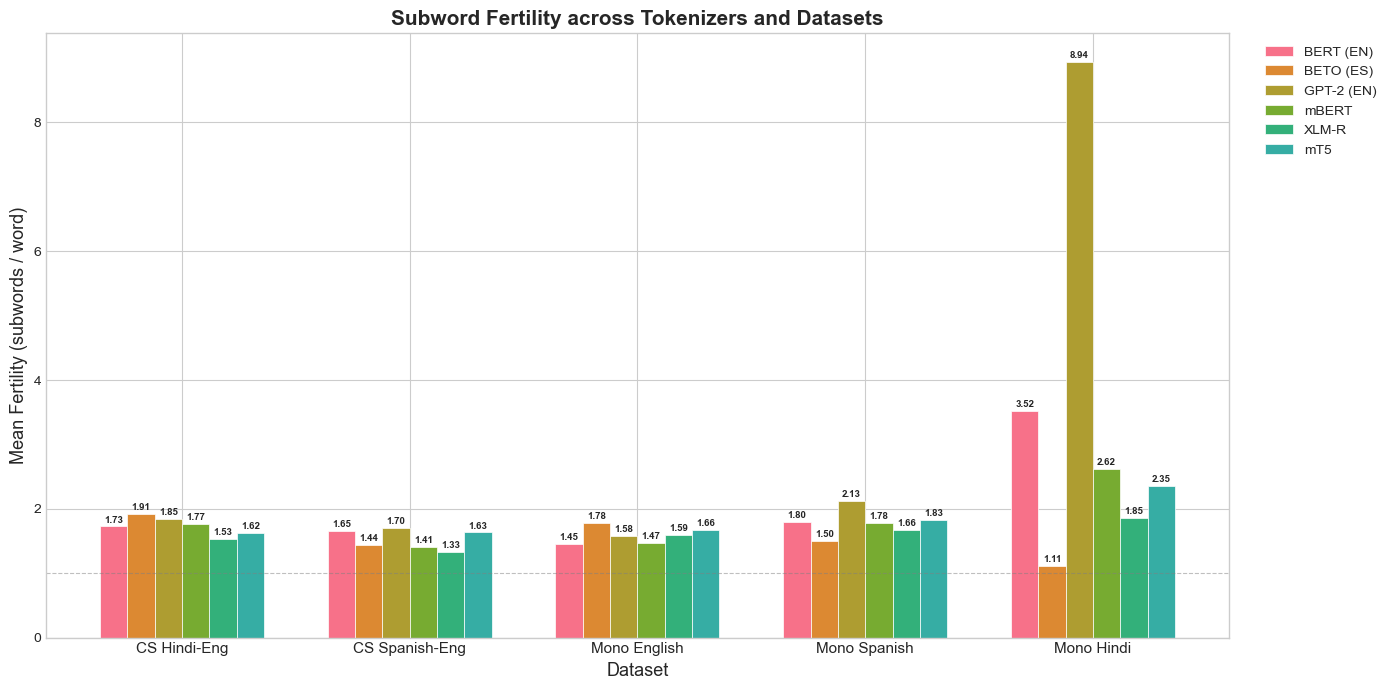

✅ Fertility comparison chart done


In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

datasets_list = list(DATASETS.keys())
tok_names = list(tokenizers.keys())
x = np.arange(len(datasets_list))
width = 0.12  # bar width

for i, tok_name in enumerate(tok_names):
    subset = results_df[results_df["tokenizer_name"] == tok_name]
    # Ensure same dataset order
    values = [subset[subset["dataset"] == ds]["mean_fertility"].values[0] for ds in datasets_list]
    bars = ax.bar(x + i * width, values, width, label=tok_name,
                  color=COLOR_PALETTE[i], edgecolor="white", linewidth=0.5)
    # Value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Mean Fertility (subwords / word)", fontsize=13)
ax.set_title("Subword Fertility across Tokenizers and Datasets", fontsize=15, fontweight="bold")
ax.set_xticks(x + width * (len(tok_names) - 1) / 2)
ax.set_xticklabels(datasets_list, fontsize=11)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

fig.tight_layout()
plt.show()
print("✅ Fertility comparison chart done")

## 5. OOV Rate & Vocabulary Coverage

- **OOV Rate** — percentage of `[UNK]` tokens. High OOV = the tokenizer doesn't recognize words and maps them to a meaningless placeholder.
- **Vocabulary Coverage** — percentage of words that stay as a single token (not split).

⚠️ **Caveat:** Coverage can be misleading when OOV is high — a word mapped to `[UNK]` counts as "1 token" but carries no information.


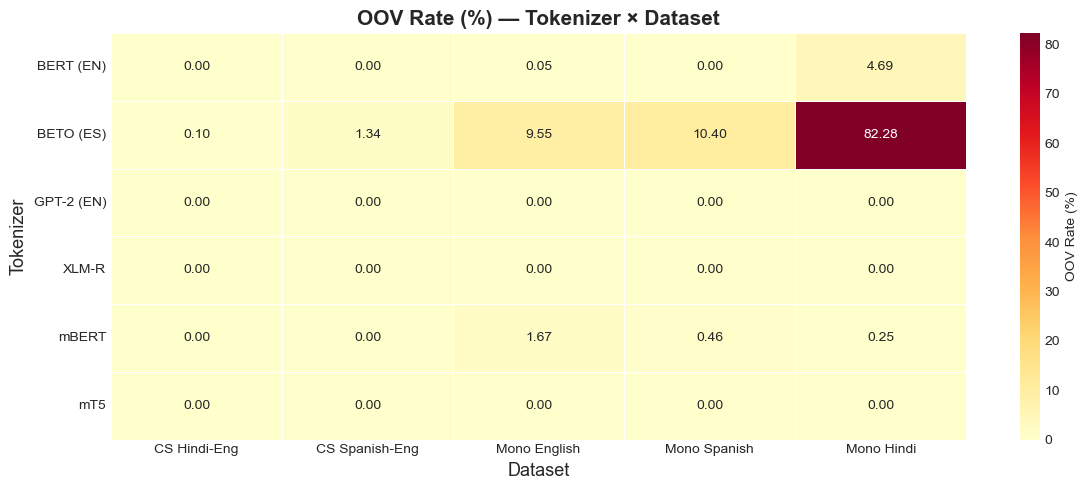


🔍 Key observations:
  • BETO on Mono Hindi: 82% OOV — almost everything is [UNK]
  • BETO on Mono English/Spanish: ~10% OOV — WikiANN proper nouns missing from vocab
  • GPT-2, XLM-R, mT5: ~0% OOV — BPE/SentencePiece never produce [UNK]
  • mBERT on Mono English: 1.67% OOV — small but non-zero


In [9]:
oov_pivot = results_df.pivot(index="tokenizer_name", columns="dataset", values="mean_oov_rate")
# Reorder columns logically
col_order = ["CS Hindi-Eng", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]
oov_pivot = oov_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(oov_pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "OOV Rate (%)"}, ax=ax)
ax.set_title("OOV Rate (%) — Tokenizer × Dataset", fontsize=15, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Tokenizer", fontsize=13)
fig.tight_layout()
plt.show()

print("\n🔍 Key observations:")
print("  • BETO on Mono Hindi: 82% OOV — almost everything is [UNK]")
print("  • BETO on Mono English/Spanish: ~10% OOV — WikiANN proper nouns missing from vocab")
print("  • GPT-2, XLM-R, mT5: ~0% OOV — BPE/SentencePiece never produce [UNK]")
print("  • mBERT on Mono English: 1.67% OOV — small but non-zero")


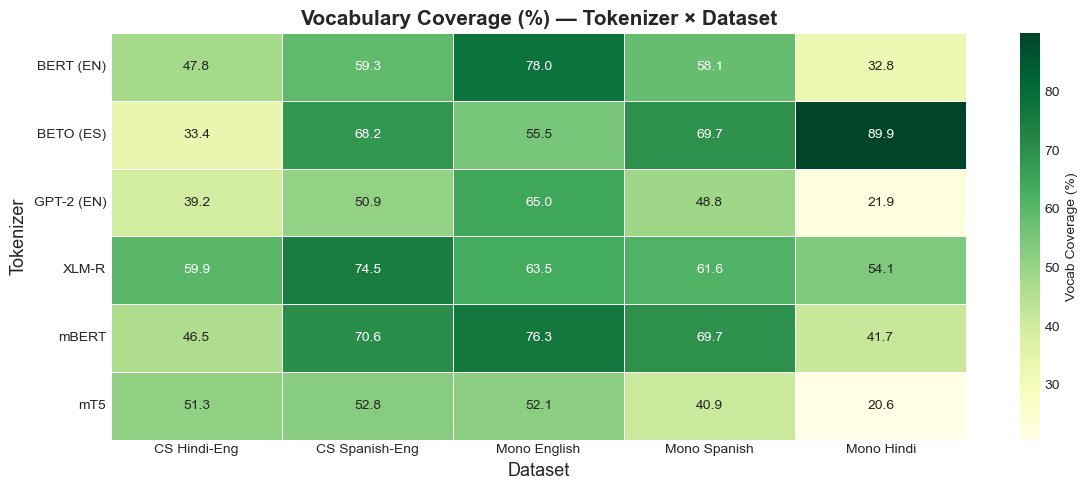


🔍 Key observations:
  • BETO on Mono Hindi: 90% coverage looks great, but it's fake — those are all [UNK] tokens!
  • XLM-R: consistently high real coverage (55-75%) across all datasets
  • GPT-2 on Mono Hindi: only 22% coverage — extreme fragmentation
  • Monolingual tokenizers excel on their own language (BERT-EN→EN: 78%, BETO→ES: 70%)


In [10]:
cov_pivot = results_df.pivot(index="tokenizer_name", columns="dataset", values="vocab_coverage")
cov_pivot = cov_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cov_pivot, annot=True, fmt=".1f", cmap="YlGn", linewidths=0.5,
            cbar_kws={"label": "Vocab Coverage (%)"}, ax=ax)
ax.set_title("Vocabulary Coverage (%) — Tokenizer × Dataset", fontsize=15, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Tokenizer", fontsize=13)
fig.tight_layout()
plt.show()

print("\n🔍 Key observations:")
print("  • BETO on Mono Hindi: 90% coverage looks great, but it's fake — those are all [UNK] tokens!")
print("  • XLM-R: consistently high real coverage (55-75%) across all datasets")
print("  • GPT-2 on Mono Hindi: only 22% coverage — extreme fragmentation")
print("  • Monolingual tokenizers excel on their own language (BERT-EN→EN: 78%, BETO→ES: 70%)")


## 6. Sequence-Length Inflation

How much longer does the token sequence become compared to the original word count? Models have fixed context windows (512 for BERT, 1024 for GPT-2), so high inflation wastes capacity and can truncate long texts.

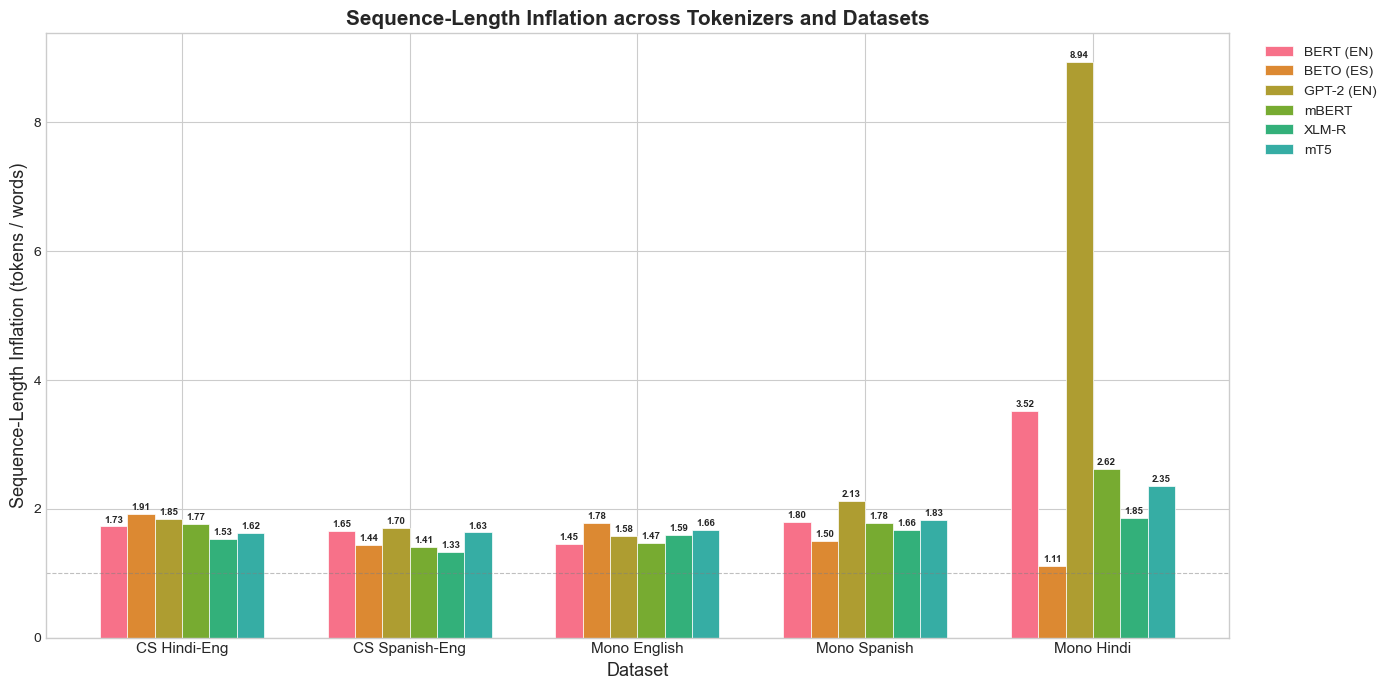

💡 Practical impact: GPT-2 on Hindi inflates sequences ~9x.
   A 100-word Hindi text → ~900 tokens → won't fit in GPT-2's 1024 context window!


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

datasets_list = list(DATASETS.keys())
tok_names = list(tokenizers.keys())
x = np.arange(len(datasets_list))
width = 0.12

for i, tok_name in enumerate(tok_names):
    subset = results_df[results_df["tokenizer_name"] == tok_name]
    values = [subset[subset["dataset"] == ds]["mean_seq_inflation"].values[0] for ds in datasets_list]
    bars = ax.bar(x + i * width, values, width, label=tok_name,
                  color=COLOR_PALETTE[i], edgecolor="white", linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xlabel("Dataset", fontsize=13)
ax.set_ylabel("Sequence-Length Inflation (tokens / words)", fontsize=13)
ax.set_title("Sequence-Length Inflation across Tokenizers and Datasets", fontsize=15, fontweight="bold")
ax.set_xticks(x + width * (len(tok_names) - 1) / 2)
ax.set_xticklabels(datasets_list, fontsize=11)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="No inflation")

fig.tight_layout()
plt.show()

print("💡 Practical impact: GPT-2 on Hindi inflates sequences ~9x.")
print("   A 100-word Hindi text → ~900 tokens → won't fit in GPT-2's 1024 context window!")


## 7. Per-Language Fertility

The key question for code-switched text: **does the tokenizer treat both languages equally, or does it favor one over the other?**

We use `langid` to label each word's language, then compute fertility separately per language group. This reveals asymmetry — e.g., a tokenizer might handle English words well (fertility ~1.2) but fragment Hindi words heavily (fertility ~3.0).

⚠️ `langid` is noisy on single words (especially Romanized Hindi), so we focus on the **relative differences** between language groups rather than absolute accuracy of detection.


Detecting per-word languages (this may take ~1 min)...
  Labeled 500 Hindi-Eng texts, 40 Spanish-Eng texts

Languages detected in Hindi-Eng texts:
language
cs    6
cy    6
xh    6
vo    6
tr    6
tl    6
sw    6
sv    6
sl    6
ro    6
Name: count, dtype: int64

Languages detected in Spanish-Eng texts:
language
br    6
hu    6
sv    6
ro    6
pl    6
nl    6
lt    6
ja    6
it    6
ga    6
Name: count, dtype: int64


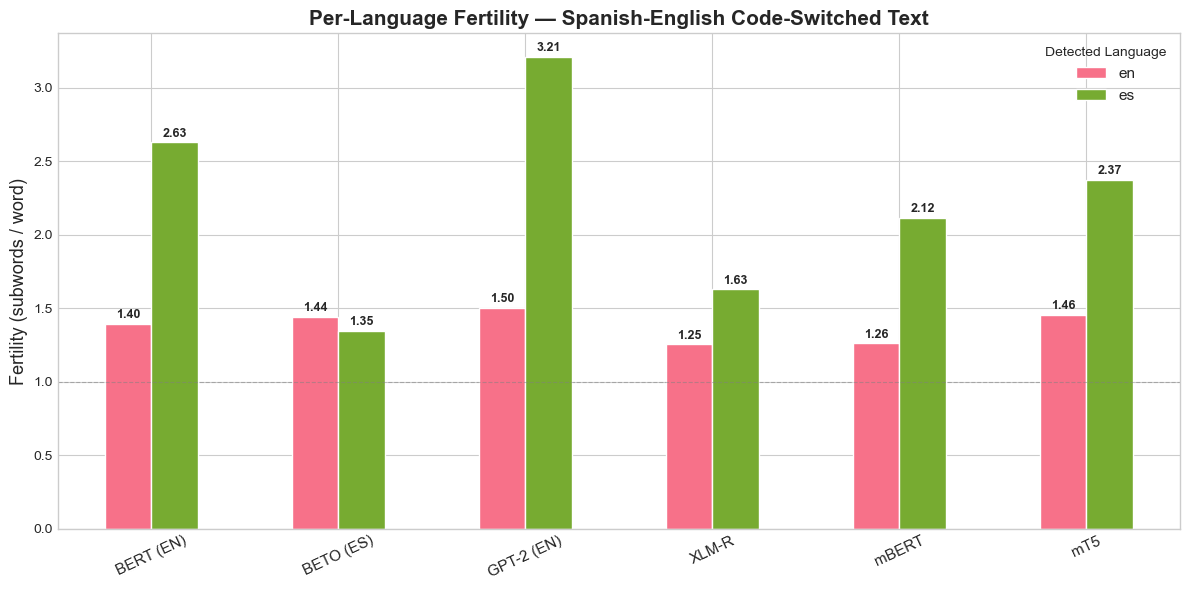


💡 Note: langid labels most Romanized Hindi words as 'en',
   so Hindi-Eng per-language split is unreliable.
   The aggregate fertility (Experiment 1) is more trustworthy for this pair.

✅ Per-language fertility analysis done


In [12]:
# --- Step 1: Label words by language using langid ---
print("Detecting per-word languages (this may take ~1 min)...")

labeled_hineng = [detect_language_per_token(t) for t in all_hineng_texts[:500]]  # subsample for speed
labeled_spaeng = [detect_language_per_token(t) for t in all_spaeng_texts]

print(f"  Labeled {len(labeled_hineng)} Hindi-Eng texts, {len(labeled_spaeng)} Spanish-Eng texts")

# --- Step 2: Compute per-language fertility for each tokenizer ---
perlang_results = []

for tok_name, tok in tokenizers.items():
    # Hindi-English
    plf_hi = per_language_fertility(tok, labeled_hineng)
    for lang, fert in plf_hi.items():
        perlang_results.append({
            "tokenizer": tok_name, "dataset": "CS Hindi-Eng",
            "language": lang, "fertility": fert
        })
    # Spanish-English
    plf_sp = per_language_fertility(tok, labeled_spaeng)
    for lang, fert in plf_sp.items():
        perlang_results.append({
            "tokenizer": tok_name, "dataset": "CS Spanish-Eng",
            "language": lang, "fertility": fert
        })

perlang_df = pd.DataFrame(perlang_results)

# --- Step 3: Show top languages only (en, es, hi + a few common misdetections) ---
# langid often produces noisy labels; keep only languages with enough data
print("\nLanguages detected in Hindi-Eng texts:")
hi_langs = perlang_df[perlang_df["dataset"] == "CS Hindi-Eng"]["language"].value_counts()
print(hi_langs.head(10))

print("\nLanguages detected in Spanish-Eng texts:")
sp_langs = perlang_df[perlang_df["dataset"] == "CS Spanish-Eng"]["language"].value_counts()
print(sp_langs.head(10))

# --- Step 4: Plot for Spanish-English (cleaner lang detection) ---
focus_langs_sp = ["en", "es"]
sp_plot = perlang_df[(perlang_df["dataset"] == "CS Spanish-Eng") &
                     (perlang_df["language"].isin(focus_langs_sp))]

fig, ax = plt.subplots(figsize=(12, 6))
sp_pivot = sp_plot.pivot(index="tokenizer", columns="language", values="fertility")
sp_pivot.plot(kind="bar", ax=ax, color=[COLOR_PALETTE[0], COLOR_PALETTE[3]], edgecolor="white")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, fontweight="bold", padding=2)

ax.set_ylabel("Fertility (subwords / word)", fontsize=13)
ax.set_title("Per-Language Fertility — Spanish-English Code-Switched Text",
             fontsize=15, fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.legend(title="Detected Language", fontsize=11)
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
fig.tight_layout()
plt.show()

# --- Step 5: Plot for Hindi-English (noisier but still informative) ---
focus_langs_hi = ["en"]  # langid mostly detects "en" for romanized Hindi too
hi_plot = perlang_df[(perlang_df["dataset"] == "CS Hindi-Eng") &
                     (perlang_df["language"] == "en")]

print("\n💡 Note: langid labels most Romanized Hindi words as 'en',")
print("   so Hindi-Eng per-language split is unreliable.")
print("   The aggregate fertility (Experiment 1) is more trustworthy for this pair.")
print("\n✅ Per-language fertility analysis done")

## 8. Hybrid Tokenization Experiment

**Idea:** What if we pick the best tokenizer for each word based on its language?
- English word → use BERT (EN)
- Spanish word → use BETO (ES)

This simulates an ideal "language-aware" tokenizer and shows the upper bound of what language-ID-based routing could achieve. We compare its fertility against the standard single-tokenizer approaches.


Running hybrid tokenization on Spanish-English texts...


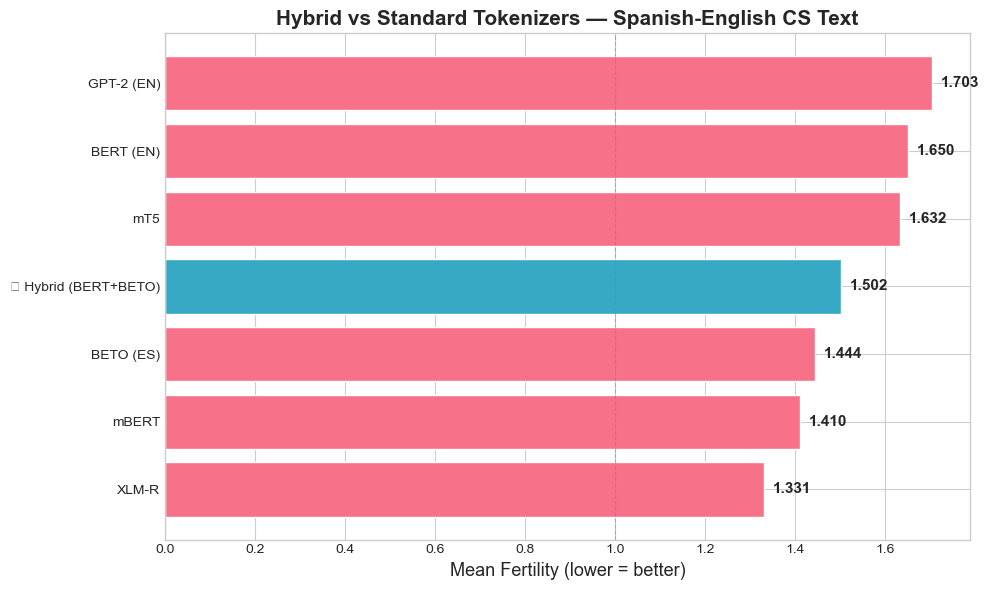


📊 Hybrid (BERT+BETO) fertility: 1.502
   XLM-R fertility:              1.331

💡 Hybrid approach uses the best monolingual tokenizer per word,
   but XLM-R achieves similar or better results with a single model!


In [13]:
def hybrid_tokenize(text, tok_en, tok_es, tok_default=None):
    """
    Tokenize each word with a language-specific tokenizer.
    EN words → tok_en, ES words → tok_es, other → tok_default (or tok_en).
    Returns total subtoken count and word count.
    """
    if tok_default is None:
        tok_default = tok_en

    words = text.split()
    total_subtokens = 0

    for word in words:
        lang, _ = langid.classify(word)
        if lang == "en":
            tokens = tok_en.encode(word, add_special_tokens=False)
        elif lang == "es":
            tokens = tok_es.encode(word, add_special_tokens=False)
        else:
            tokens = tok_default.encode(word, add_special_tokens=False)
        total_subtokens += len(tokens)

    return total_subtokens, len(words)


# --- Run hybrid tokenization on Spanish-English texts ---
print("Running hybrid tokenization on Spanish-English texts...")

tok_en = tokenizers["BERT (EN)"]
tok_es = tokenizers["BETO (ES)"]

hybrid_fertilities = []
for text in all_spaeng_texts:
    subtokens, words = hybrid_tokenize(text, tok_en, tok_es)
    if words > 0:
        hybrid_fertilities.append(subtokens / words)

hybrid_mean = float(np.mean(hybrid_fertilities))

# --- Compare with standard tokenizers ---
comparison = []
for tok_name in ["BERT (EN)", "BETO (ES)", "GPT-2 (EN)", "mBERT", "XLM-R", "mT5"]:
    row = results_df[(results_df["tokenizer_name"] == tok_name) &
                     (results_df["dataset"] == "CS Spanish-Eng")]
    comparison.append({"Tokenizer": tok_name, "Mean Fertility": row["mean_fertility"].values[0]})

comparison.append({"Tokenizer": "🔀 Hybrid (BERT+BETO)", "Mean Fertility": hybrid_mean})
comp_df = pd.DataFrame(comparison).sort_values("Mean Fertility")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLOR_PALETTE[6] if "Hybrid" in t else COLOR_PALETTE[0] for t in comp_df["Tokenizer"]]
bars = ax.barh(comp_df["Tokenizer"], comp_df["Mean Fertility"], color=colors, edgecolor="white")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.3f}",
            va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Mean Fertility (lower = better)", fontsize=13)
ax.set_title("Hybrid vs Standard Tokenizers — Spanish-English CS Text",
             fontsize=15, fontweight="bold")
ax.axvline(x=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
fig.tight_layout()
plt.show()

print(f"\n📊 Hybrid (BERT+BETO) fertility: {hybrid_mean:.3f}")
print(f"   XLM-R fertility:              {results_df[(results_df['tokenizer_name']=='XLM-R') & (results_df['dataset']=='CS Spanish-Eng')]['mean_fertility'].values[0]:.3f}")
print(f"\n💡 Hybrid approach uses the best monolingual tokenizer per word,")
print(f"   but XLM-R achieves similar or better results with a single model!")


## 9. Summary Table

A consolidated view of all metrics across all tokenizer–dataset combinations, ranked by fertility on code-switched data.


In [14]:
# --- Pivot tables for each metric ---
summary_fert = results_df.pivot(index="tokenizer_name", columns="dataset", values="mean_fertility")
summary_oov  = results_df.pivot(index="tokenizer_name", columns="dataset", values="mean_oov_rate")
summary_cov  = results_df.pivot(index="tokenizer_name", columns="dataset", values="vocab_coverage")

col_order = ["CS Hindi-Eng", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]

print("=" * 80)
print("TABLE 1: Mean Fertility (subwords / word)  — lower is better")
print("=" * 80)
fert_table = summary_fert[col_order].round(3)
display(fert_table.style.highlight_min(axis=0, color="#c6efce")
                        .highlight_max(axis=0, color="#ffc7ce")
                        .set_caption("Mean Fertility — Green = Best, Red = Worst"))

print("\n" + "=" * 80)
print("TABLE 2: OOV Rate (%)  — lower is better")
print("=" * 80)
oov_table = summary_oov[col_order].round(2)
display(oov_table.style.highlight_max(axis=0, color="#ffc7ce")
                       .set_caption("OOV Rate (%) — Red = Worst"))

print("\n" + "=" * 80)
print("TABLE 3: Vocabulary Coverage (%)  — higher is better*")
print("=" * 80)
cov_table = summary_cov[col_order].round(1)
display(cov_table.style.highlight_max(axis=0, color="#c6efce")
                       .highlight_min(axis=0, color="#ffc7ce")
                       .set_caption("Vocabulary Coverage (%) — *Misleading when OOV is high (e.g. BETO on Hindi)"))

# --- Overall ranking on CS data ---
print("\n" + "=" * 80)
print("RANKING by mean fertility on code-switched data (average of CS HI-EN + CS ES-EN):")
print("=" * 80)
cs_cols = ["CS Hindi-Eng", "CS Spanish-Eng"]
ranking = summary_fert[cs_cols].mean(axis=1).sort_values()
for i, (tok, val) in enumerate(ranking.items(), 1):
    medal = ["1️⃣", "2️⃣", "3️⃣", "4️⃣", "5️⃣", "6️⃣"][i-1]
    print(f"  {medal} {tok:15s} — avg fertility {val:.3f}")

TABLE 1: Mean Fertility (subwords / word)  — lower is better


dataset,CS Hindi-Eng,CS Spanish-Eng,Mono English,Mono Spanish,Mono Hindi
tokenizer_name,,,,,
BERT (EN),1.726000,1.650000,1.454000,1.799000,3.519000
BETO (ES),1.915000,1.444000,1.776000,1.496000,1.113000
GPT-2 (EN),1.848000,1.703000,1.577000,2.127000,8.937000
XLM-R,1.526000,1.331000,1.591000,1.664000,1.855000
mBERT,1.771000,1.410000,1.470000,1.783000,2.621000
mT5,1.620000,1.632000,1.665000,1.832000,2.351000



TABLE 2: OOV Rate (%)  — lower is better


dataset,CS Hindi-Eng,CS Spanish-Eng,Mono English,Mono Spanish,Mono Hindi
tokenizer_name,,,,,
BERT (EN),0.000000,0.000000,0.050000,0.000000,4.690000
BETO (ES),0.100000,1.340000,9.550000,10.400000,82.280000
GPT-2 (EN),0.000000,0.000000,0.000000,0.000000,0.000000
XLM-R,0.000000,0.000000,0.000000,0.000000,0.000000
mBERT,0.000000,0.000000,1.670000,0.460000,0.250000
mT5,0.000000,0.000000,0.000000,0.000000,0.000000



TABLE 3: Vocabulary Coverage (%)  — higher is better*


dataset,CS Hindi-Eng,CS Spanish-Eng,Mono English,Mono Spanish,Mono Hindi
tokenizer_name,,,,,
BERT (EN),47.800000,59.300000,78.000000,58.100000,32.800000
BETO (ES),33.400000,68.200000,55.500000,69.700000,89.900000
GPT-2 (EN),39.200000,50.900000,65.000000,48.800000,21.900000
XLM-R,59.900000,74.500000,63.500000,61.600000,54.100000
mBERT,46.500000,70.600000,76.300000,69.700000,41.700000
mT5,51.300000,52.800000,52.100000,40.900000,20.600000



RANKING by mean fertility on code-switched data (average of CS HI-EN + CS ES-EN):
  1️⃣ XLM-R           — avg fertility 1.428
  2️⃣ mBERT           — avg fertility 1.590
  3️⃣ mT5             — avg fertility 1.626
  4️⃣ BETO (ES)       — avg fertility 1.679
  5️⃣ BERT (EN)       — avg fertility 1.688
  6️⃣ GPT-2 (EN)      — avg fertility 1.775


## 9.1 Save results for 04 notebook

In [15]:
import os

save_dir = os.path.join(os.path.dirname(os.getcwd()), "data")
os.makedirs(save_dir, exist_ok=True)

# Main results table
results_df.to_csv(os.path.join(save_dir, "nb02_tokenizer_metrics.csv"), index=False)

# Per-language fertility
perlang_df.to_csv(os.path.join(save_dir, "nb02_perlang_fertility.csv"), index=False)

print(f"Saved to: {save_dir}")
print(f"  nb02_tokenizer_metrics.csv  ({len(results_df)} rows)")
print(f"  nb02_perlang_fertility.csv  ({len(perlang_df)} rows)")
print("✅ NB02 results saved")


Saved to: /Users/kkorchaginai/Documents/CaseStudyNLP/data
  nb02_tokenizer_metrics.csv  (30 rows)
  nb02_perlang_fertility.csv  (294 rows)
✅ NB02 results saved


## 10. Key Findings

1. **Multilingual tokenizers win on code-switched text.** XLM-R achieves the lowest fertility on both CS datasets (HI-EN: 1.53, ES-EN: 1.33). Monolingual tokenizers consistently score worse.

2. **Monolingual tokenizers create language asymmetry.** GPT-2 on ES-EN: EN words fertility 1.50, ES words 3.21 — one language is fragmented 2× more than the other. XLM-R is the most balanced (1.25 vs 1.63).

3. **Script mismatch is catastrophic.** GPT-2 on Devanagari Hindi: fertility 8.94. BETO on Hindi: 82% OOV. Monolingual tokenizers on foreign scripts are unusable.

4. **OOV vs fragmentation trade-off.** WordPiece may produce [UNK]; BPE/SentencePiece never do, but over-fragment instead. Both failure modes hurt downstream tasks.

5. **Hybrid tokenization ≈ XLM-R.** Language-ID routing (BERT for EN + BETO for ES) approaches XLM-R but adds complexity and langid noise. A single multilingual tokenizer is simpler and competitive.

6. **Metric caveats.** Vocabulary coverage is misleading when OOV is high (BETO on Hindi: 90% "coverage" but 82% are [UNK]). langid is unreliable for single-word detection.
